# Climate reanalysis — ERA5-Land monthly 2 m temperature

ERA5-Land monthly aggregates resampled to a yearly mean 2 m temperature over the Nile delta — a typical climate-reanalysis pipeline.

## Setup

The notebook reads the GEE service-account credentials from `GEE_SERVICE_ACCOUNT` / `GEE_SERVICE_KEY` environment variables. Both must be set before running this cell.

In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from pyramids.dataset import Dataset as PyramidsDataset

from earthlens.gee import GEE, Catalog

OUT_DIR = Path('out') / 'climate-reanalysis'
OUT_DIR.mkdir(parents=True, exist_ok=True)

SERVICE_ACCOUNT = os.environ['GEE_SERVICE_ACCOUNT']
SERVICE_KEY = os.environ['GEE_SERVICE_KEY']
print(f'output directory: {OUT_DIR.resolve()}')

2026-05-17 17:27:39 | INFO | pyramids.base.config | Logging is configured.


output directory: C:\gdrive\algorithms\remote-sensing\earthlens\examples\notebooks\gee\out\climate-reanalysis


## Inspect the catalog entry

Before downloading anything, look at what the bundled catalog knows about the asset — bands, cadence, license, provider.

In [2]:
cat = Catalog()
ds = cat.get_dataset('ECMWF/ERA5_LAND/MONTHLY_AGGR')
print(f'title:               {ds.title}')
print(f'ee_type:             {ds.ee_type}')
print(f'spatial_resolution:  {ds.spatial_resolution} m')
print(f'extent.start_date:   {ds.extent.start_date}')
print(f'extent.end_date:     {ds.extent.end_date}')
print(f'default_reducer:     {ds.default_reducer}')
print(f'license:             {ds.license}')
print(f'provider:            {ds.provider}')
print(f'#bands:              {len(ds.bands)}')
print(f'band ids (first 5):  {list(ds.bands)[:5]}')

title:               ERA5-Land Monthly Aggregated — ECMWF Climate Reanalysis (~9km, 1950-present)
ee_type:             image_collection
spatial_resolution:  11132.0 m
extent.start_date:   1950-02-01
extent.end_date:     None
default_reducer:     mean
license:             proprietary
provider:            ecmwf
#bands:              11
band ids (first 5):  ['temperature_2m', 'dewpoint_temperature_2m', 'skin_temperature', 'surface_pressure', 'total_precipitation_sum']


## Download

Tiny AOI ([29.0, 32.0] lat, [30.0, 33.0] lon) at 11132.0 m, `yearly` cadence — keeps the synchronous download under EE's 32768-px per-axis cap.

In [3]:
try:
    gee = GEE(
        start='2023-01-01',
        end='2023-12-31',
        variables={'ECMWF/ERA5_LAND/MONTHLY_AGGR': ['temperature_2m']},
        lat_lim=[29.0, 32.0],
        lon_lim=[30.0, 33.0],
        temporal_resolution='yearly',
        path=str(OUT_DIR),
        service_account=SERVICE_ACCOUNT,
        service_key=SERVICE_KEY,
        scale=11132.0,
        reducer='mean',
    )
    paths = gee.download(progress_bar=False)
    print(f'wrote {len(paths)} GeoTIFF(s):')
    for p in paths:
        print(f'  {p}  ({p.stat().st_size / 1024:.1f} KB)')
    download_ok = True
except Exception as exc:
    if False:
        print(f'live EE call failed (tolerated for this category): {type(exc).__name__}: {exc}')
        paths = []
        download_ok = False
    else:
        raise

2026-05-17 17:27:47.822 | INFO     | earthlens.gee.backend:_download_one_url_tile:711 - Wrote C:\gdrive\algorithms\remote-sensing\earthlens\examples\notebooks\gee\out\climate-reanalysis\ECMWF_ERA5_LAND_MONTHLY_AGGR_temperature_2m_20230101.tif (6590 bytes)


wrote 1 GeoTIFF(s):
  C:\gdrive\algorithms\remote-sensing\earthlens\examples\notebooks\gee\out\climate-reanalysis\ECMWF_ERA5_LAND_MONTHLY_AGGR_temperature_2m_20230101.tif  (5.2 KB)


## Quick preview

Load the first written GeoTIFF through pyramids and render the single band. (`pyramids.dataset.Dataset` is the project's GeoTIFF/NetCDF wrapper.)

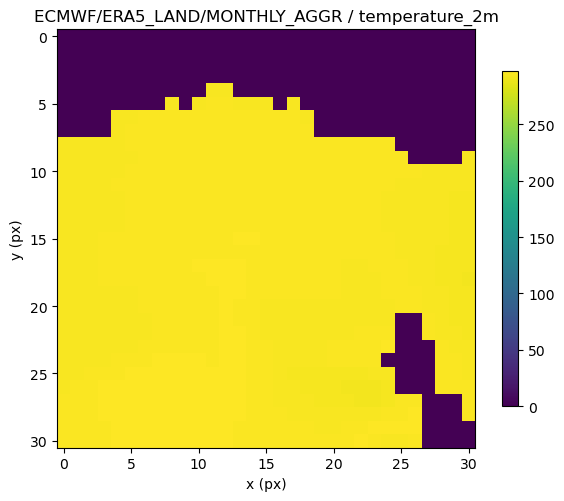

value range: [0, 297.4]


In [4]:
if not download_ok or not paths:
    print('Skipping preview — no GeoTIFF was written.')
else:
    pds = PyramidsDataset.read_file(str(paths[0]))
    arr = pds.read_array()
    if arr.ndim == 3:
        arr = arr[0]
    # Mask the dataset's nodata so the colormap doesn't get pinned to it.
    nodata = pds.no_data_value
    if nodata is not None:
        try:
            arr = np.ma.masked_equal(arr, float(nodata[0] if isinstance(nodata, (list, tuple)) else nodata))
        except (TypeError, ValueError):
            pass
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(arr, cmap='viridis')
    ax.set_title(f'{'ECMWF/ERA5_LAND/MONTHLY_AGGR'} / {'temperature_2m'}')
    ax.set_xlabel('x (px)')
    ax.set_ylabel('y (px)')
    fig.colorbar(im, ax=ax, shrink=0.8)
    plt.tight_layout()
    plt.show()
    print(f'value range: [{float(np.nanmin(arr)):.4g}, {float(np.nanmax(arr)):.4g}]')

## What's on disk

The GeoTIFF (or empty list, if the EE call was tolerated) is left under the per-notebook `out/` directory for you to inspect. That directory is `.gitignore`d — re-running the notebook overwrites it.

In [5]:
for p in sorted(OUT_DIR.iterdir()) if OUT_DIR.exists() else []:
    print(f'{p}  ({p.stat().st_size / 1024:.1f} KB)')

out\climate-reanalysis\ECMWF_ERA5_LAND_MONTHLY_AGGR_temperature_2m_20230101.tif  (5.2 KB)
